INX Future Inc. Employee Performance Analysis

Exploratory Data Analysis

This notebook focuses on exploring the INX Future Inc. employee performance dataset to identify the patterns and relationships between employee characteristics and also their performance ratings.

This analysis aims to provide an insights into the employee performance and also address the key business requirements of the project, including department wise performance and factors that may be associated with the employee performance.

Import Libraries

The Python libraries are used for exploratory data analysis and visualization. Pandas is used for data manipulation, while Matplotlib and Seaborn are used to create charts and visualize relationships within the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import the Dataset

The employee performance dataset is imported into a pandas Dataframe for exploratory analysis.

In [3]:
df = pd.read_excel("/content/INX_Future_Inc_Employee_Performance.xlsx")

Initial Data Inspection

The dataset is briefly inspected to confirm that it has been loaded correctly before performing the exploratory analysis.

In [4]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


This is done to just confirm if thedata is available.

**Exploratory Data Analysis**

**Overall Performance Rating Distribution**

The distribution of Performance Rating is examined in order to understand the overall performance levels of employees in INX Future Inc.

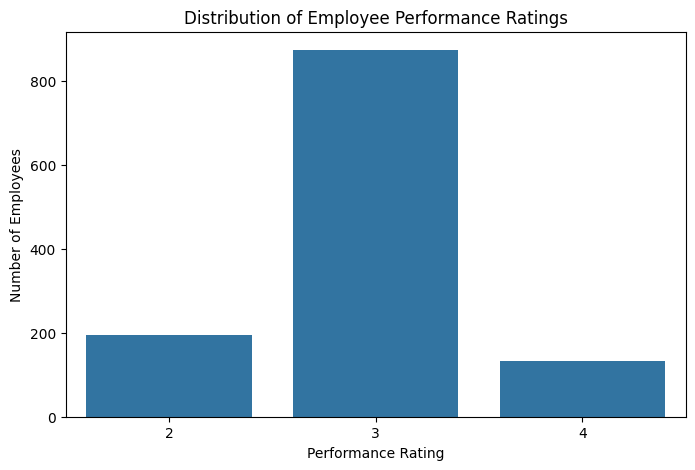

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='PerformanceRating'
)

plt.title('Distribution of Employee Performance Ratings')
plt.xlabel('Performance Rating')
plt.ylabel('Number of Employees')
plt.show()

Performance Rating 3 has the highest number of employees.Making it the most common performance rating in the dataset.

**Department Wise Performance**

The distribution of employee performance ratings across departments is analyzed in order to determine whether performance differs between departments.

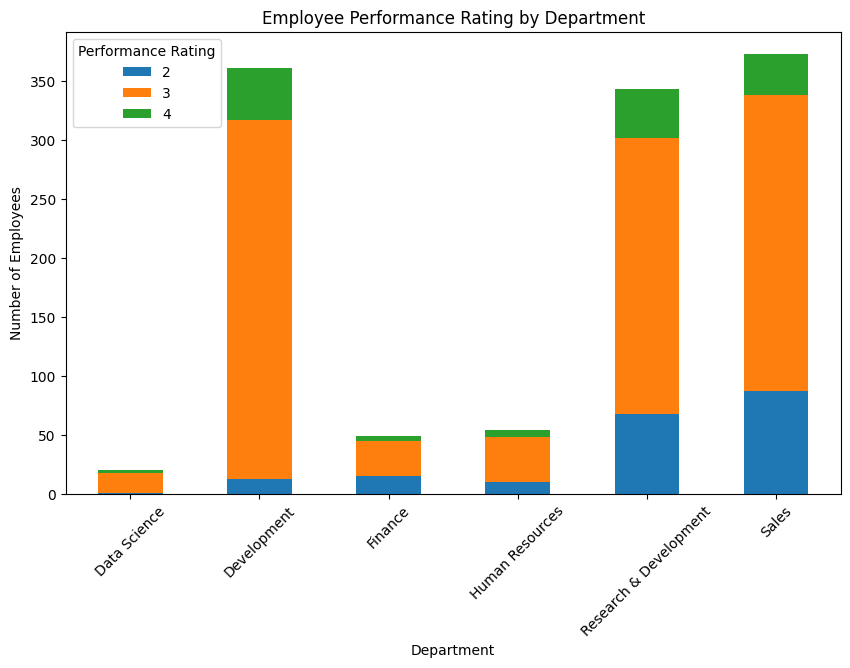

In [6]:
department_performance = pd.crosstab(
    df['EmpDepartment'],
    df['PerformanceRating']
)

department_performance.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Employee Performance Rating by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.legend(title='Performance Rating')
plt.xticks(rotation=45)
plt.show()

The Sales, Development and Research & Development departments have the largest workforces. Performance Rating 3 is the most common rating in every department. Sales and Research & Development each have a much higher proportion of low performers (Rating 2) than other departments, whereas Development has the smallest share of low-rated employees. In contrast, each department has a similar percentage (around 10–15%) of top performers (Rating 4). These findings suggest that improvement efforts should focus on the causes of low performance in Sales and Research & Development.

**Gender and Perfomance Rating**

The relationship between gender and employee performance rating is examined to determine whether performance patterns differ between gender groups.


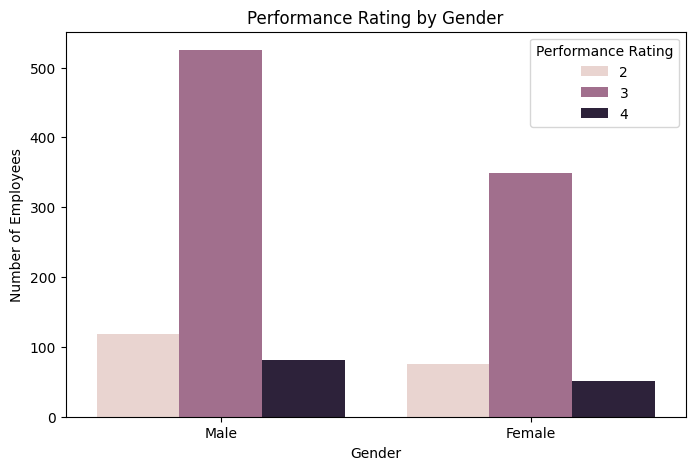

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Gender',
    hue='PerformanceRating'
)

plt.title('Performance Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Employees')
plt.legend(title='Performance Rating')
plt.show()

Male employees make up a larger proportion of the workforce than female employees.However the similarity in performance rating distributions suggests that gender is not a major factor associated with differences in employee performance ratings in this dataset.INX Future Inc does not appear to have a substantial gender based difference in performance ratings based on this analysis. However, further statistical testing would be required to formally establish whether any difference is statistically significant.

**Education Level and Performance Rating**

The relationship between education level and employee performance is examined to determine whether employees with different education levels show differences in their performance ratings.

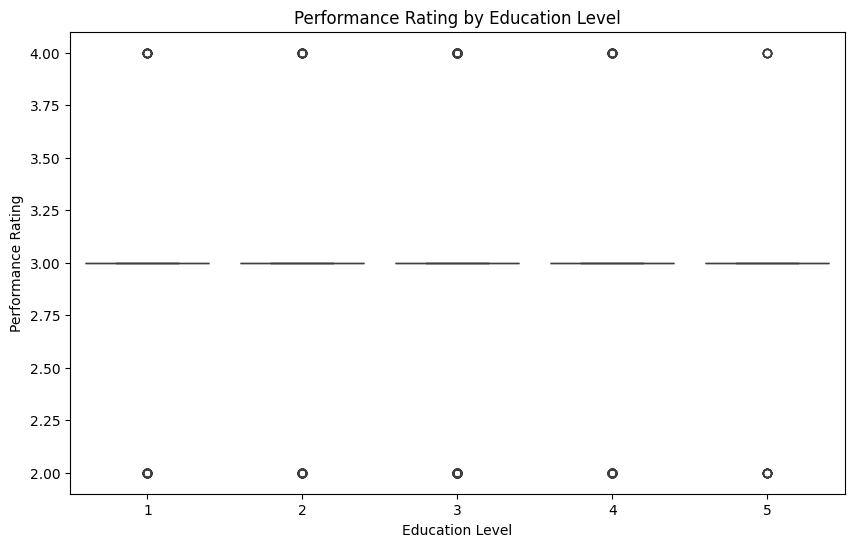

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='EmpEducationLevel',
    y='PerformanceRating'
)

plt.title('Performance Rating by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Performance Rating')
plt.show()

The chart shows that Employees with different levels of formal education receive broadly similar performance ratings. There is no obvious pattern showing that higher educational attainment consistently results in higher performance ratings.
Education level alone does not appear to be a strong indicator of employee performance in this dataset. INX Future Inc should therefore consider practical workplace factors and employee characteristics alongside academic qualifications when evaluating performance.

**Job Role and Performance Rating**

Employee performance is examined across different job roles to identify whether some roles have noticeably different performance patterns.

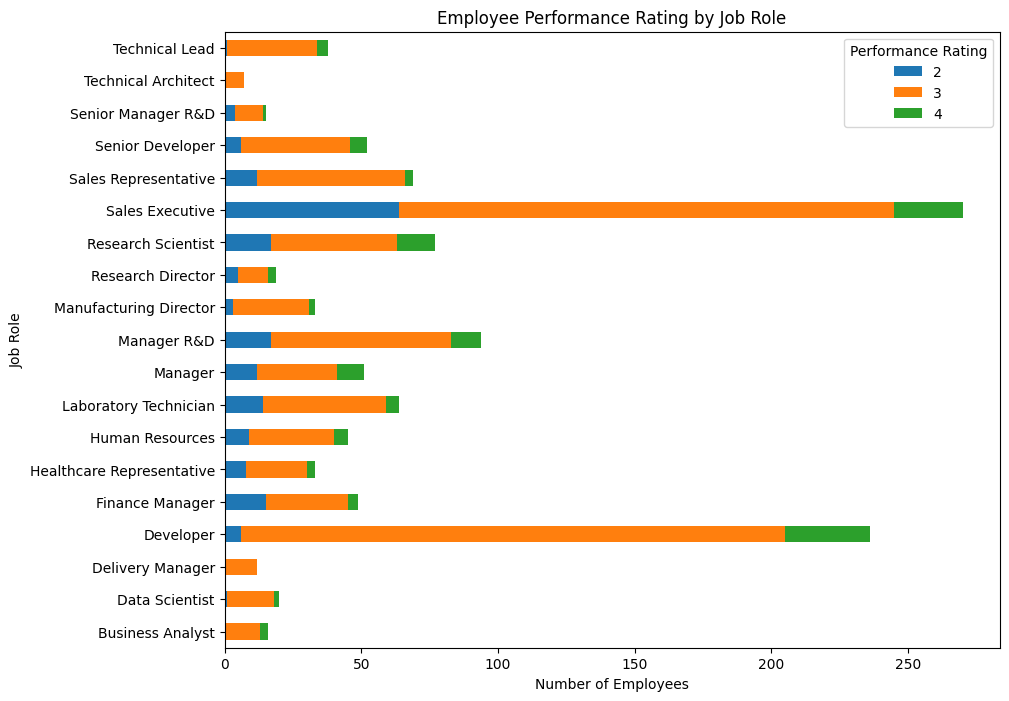

In [9]:
job_role_performance = pd.crosstab(
    df['EmpJobRole'],
    df['PerformanceRating']
)

job_role_performance.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 8)
)

plt.title('Employee Performance Rating by Job Role')
plt.xlabel('Number of Employees')
plt.ylabel('Job Role')
plt.legend(title='Performance Rating')
plt.show()

Sales Executives and Developers represent some of the largest employee groups in the organization.The higher number of Rating 2 employees among Sales Executives may partly reflect the larger size of this employee group. However, the relatively lower concentration of poor ratings among Developers suggests that job role may be associated with differences in performance outcomes.INX Future Inc should investigate why lower performance is more common among certain job roles, particularly Sales. Factors such as workload, targets, management practices, job demands, or employee satisfaction could be examined further.

**Years at Company and Performance Rating**

The relationship between an employee's years at the company and their performance rating is also examined to determine whether performance changes with employee tenure.

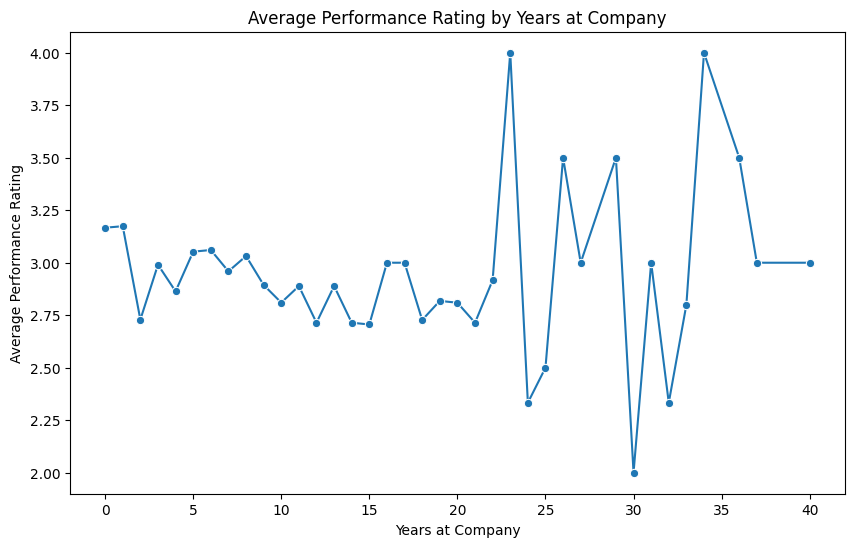

In [10]:
years_performance = (
    df.groupby('ExperienceYearsAtThisCompany')['PerformanceRating']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=years_performance,
    x='ExperienceYearsAtThisCompany',
    y='PerformanceRating',
    marker='o'
)

plt.title('Average Performance Rating by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Average Performance Rating')
plt.show()

The chart indicates that there is no clear evidence of a consistent relationship between employee tenure and performance during the first 22 years. The extreme fluctuations among employees with very long tenure are likely influenced by the small number of employees in these groups.Years of service alone does not appear to be a reliable predictor of employee performance. INX Future Inc should avoid assuming that longer-serving employees will necessarily perform better or worse.

**Job Satisfaction and Performance Rating**

The relationship between job satisfaction and employee performance is examined to determine whether employees with different satisfaction levels have different performance patterns.

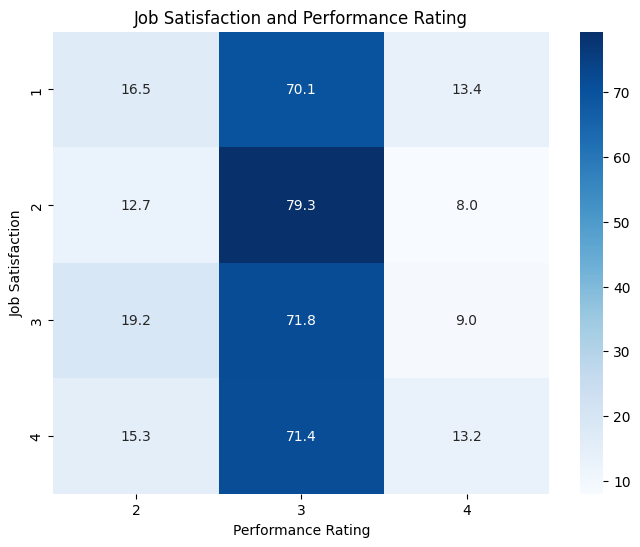

In [11]:
job_satisfaction_performance = pd.crosstab(
    df['EmpJobSatisfaction'],
    df['PerformanceRating'],
    normalize='index'
) * 100

plt.figure(figsize=(8, 6))

sns.heatmap(
    job_satisfaction_performance,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Job Satisfaction and Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Job Satisfaction')
plt.show()

Employees with different levels of job satisfaction receive broadly similar performance ratings. Although some differences may exist between satisfaction levels, there is no strong visual pattern showing that increasing job satisfaction consistently leads to higher performance ratings.
Job satisfaction alone does not appear to be a strong predictor of performance rating in this dataset. INX Future Inc should consider other workplace factors that may have a stronger relationship with performance.

**Work-Life Balance and Performance Rating**

The relationship between work-life balance and employee performance is examined to determine whether performance patterns differ across work-life balance levels.

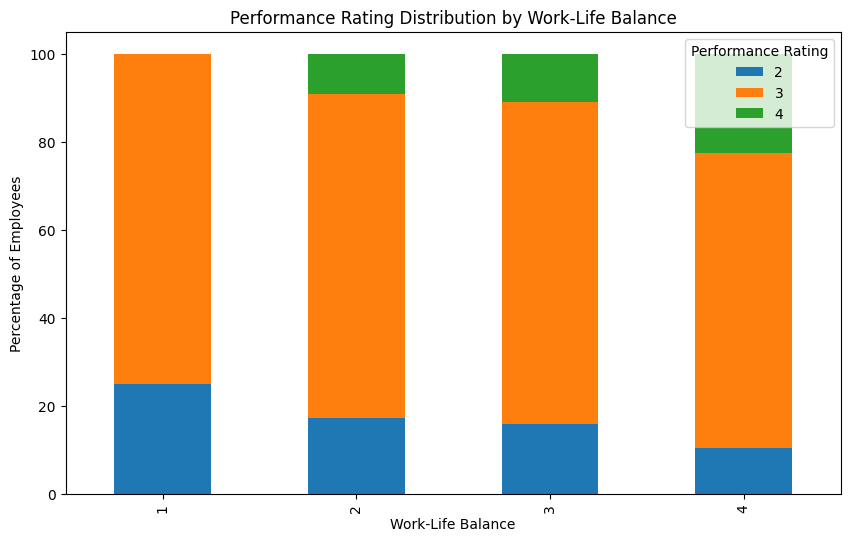

In [12]:
worklife_performance = pd.crosstab(
    df['EmpWorkLifeBalance'],
    df['PerformanceRating'],
    normalize='index'
) * 100

worklife_performance.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Performance Rating Distribution by Work-Life Balance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Percentage of Employees')
plt.legend(title='Performance Rating')
plt.show()

The chat suggests a potentially meaningful relationship between work life balance and employee performance. Employees experiencing very poor work life balance appear more likely to receive lower performance ratings.
Work-life balance may be an important factor for INX Future Inc to address. Improving workload management, scheduling, flexibility, or employee support could potentially help reduce underperformance.

**Salary Hike and Performance Rating**

The rlationship between salary hike percentage and employee performance rating is examined to determine whether higher salary increases are associated with differences in performance.

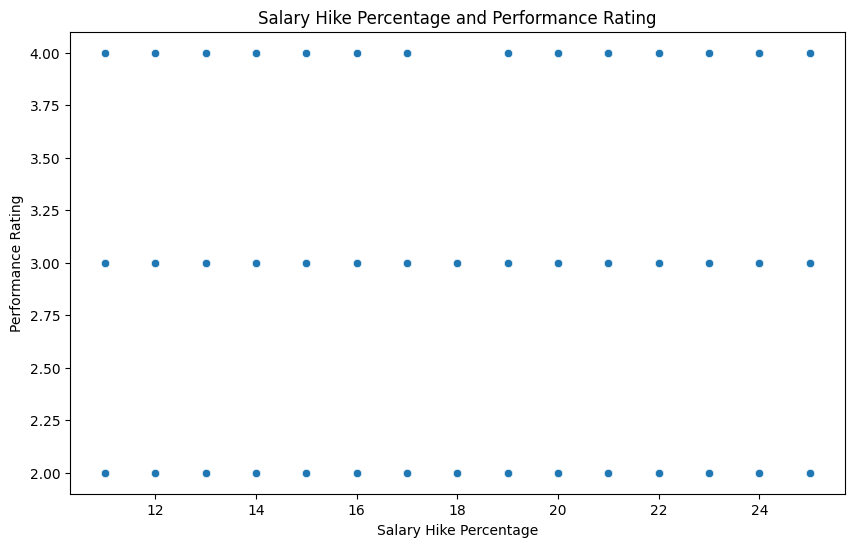

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='EmpLastSalaryHikePercent',
    y='PerformanceRating'
)

plt.title('Salary Hike Percentage and Performance Rating')
plt.xlabel('Salary Hike Percentage')
plt.ylabel('Performance Rating')
plt.show()

The chart shows salary hike percentage does not appear to have a straightforward relationship with employee performance ratings. Employees receiving both relatively low and relatively high salary increases can receive different performance ratings.
Salary increases alone should not be treated as a reliable indicator or predictor of employee performance. INX Future Inc should consider performance-related factors independently when making compensation decisions.

**Environment Satisfaction and Performance Rating**

The relationship between environment satisfaction and employee performance is examined whether workplace environment satisfaction is associated with employee performance ratings.

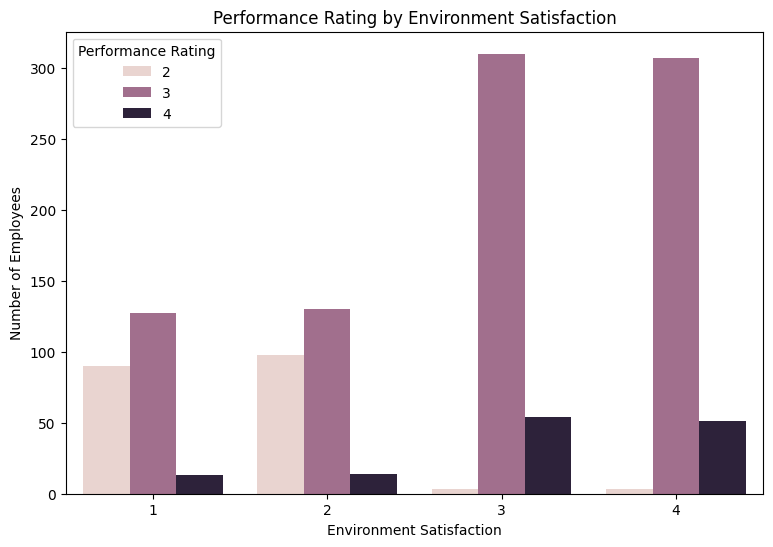

In [14]:
plt.figure(figsize=(9, 6))
sns.countplot(
    data=df,
    x='EmpEnvironmentSatisfaction',
    hue='PerformanceRating'
)

plt.title('Performance Rating by Environment Satisfaction')
plt.xlabel('Environment Satisfaction')
plt.ylabel('Number of Employees')
plt.legend(title='Performance Rating')
plt.show()

Employees with low Environment Satisfaction levels (1 and 2) account for a large share of Rating 2 performance scores.The pattern suggests that the quality of the work environment may be associated with employee performance. Employees who report higher satisfaction with their working environment appear less likely to receive low performance ratings.Work environment satisfaction could be an important area for INX Future Inc management to investigate. Improving workplace conditions and employee experience may help address low performance.

**Overall Exploratory Data Analysis Findings**

Overall, Performance Rating 3 is the dominant rating across the organization. The most notable differences are concentrated in low performance, particularly within Sales and Research & Development. Work-life balance and environment satisfaction show stronger associations with performance, while gender, education level, tenure, job satisfaction, and salary hike show relatively weaker patterns. These findings suggest that INX should focus improvement efforts on workplace conditions, employee well-being, and role-specific factors contributing to underperformance.